In [144]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.decomposition import PCA

In [145]:
# Problem 1: Load Iris dataset and train Decision Trees with varying depths
iris_data = load_iris()
df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
df['target'] = iris_data.target
print(df.tail())

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     target  
145       2  
146       2  
147       2  
148       2  
149       2  


In [146]:
X = df.drop('target', axis=1) 
y = df['target']              

# Divide the training set into the test set on an 80/20 basis
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [147]:
results = []

for depth in range(1, 6):
    clf = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=2, min_samples_split=5, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    
    report = classification_report(y_test, y_pred, zero_division=0,output_dict=True)
    
    results.append({
        'depth': depth,
        'precision': report['macro avg']['precision'],
        'recall': report['macro avg']['recall'],
        'f1_score': report['macro avg']['f1-score']
    })


results_df = pd.DataFrame(results)
print(results_df)


   depth  precision    recall  f1_score
0      1   0.483333  0.666667  0.540230
1      2   0.972222  0.962963  0.965899
2      3   1.000000  1.000000  1.000000
3      4   1.000000  1.000000  1.000000
4      5   1.000000  1.000000  1.000000


In [148]:
# Problem 2: Load Breast Cancer dataset (discrete) and compute entropy, gini, misclassification error
column_names = ['ID', 'Clump_Thickness', 'Uniformity_of_Cell_Size', 'Uniformity_of_Cell_Shape', 'Marginal_Adhesion',
                'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class']
data = pd.read_csv('datasets\\breast-cancer-wisconsin.data', 
                   header=None, names=column_names,na_values=['?', ' ', 'NaN'])
cancer_data=data.dropna().copy()
cancer_data['Class'] = cancer_data['Class'].map({2: 0, 4: 1})


In [149]:
X=cancer_data.drop(['ID', 'Class'], axis=1)
y=cancer_data['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


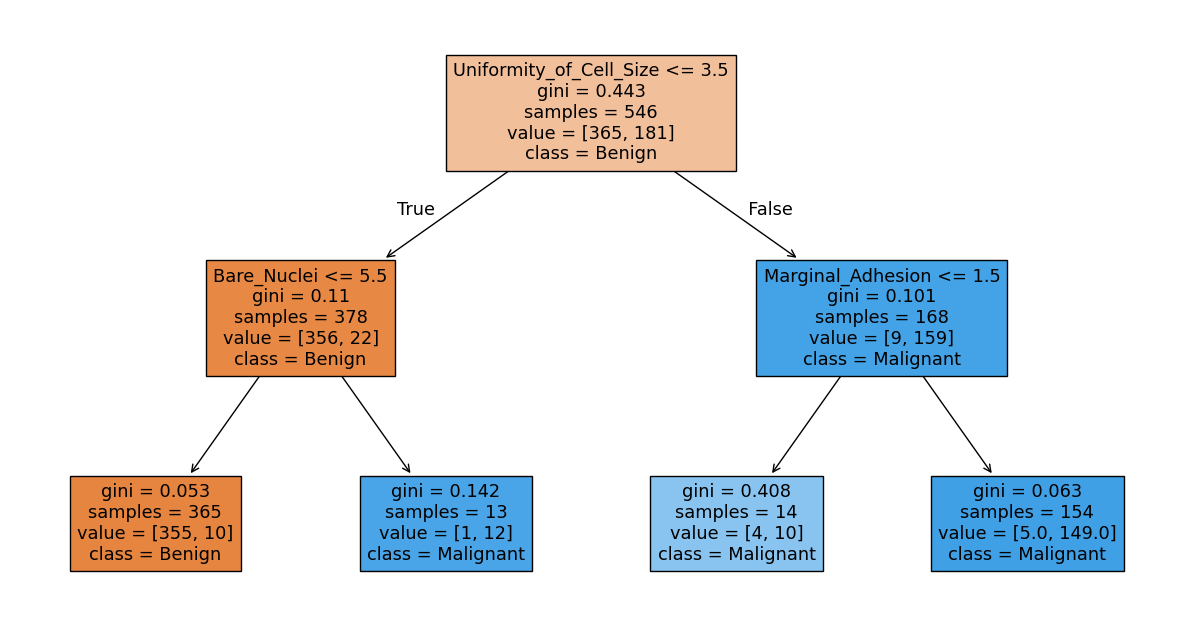

|--- Uniformity_of_Cell_Size <= 3.50
|   |--- Bare_Nuclei <= 5.50
|   |   |--- class: 0
|   |--- Bare_Nuclei >  5.50
|   |   |--- class: 1
|--- Uniformity_of_Cell_Size >  3.50
|   |--- Marginal_Adhesion <= 1.50
|   |   |--- class: 1
|   |--- Marginal_Adhesion >  1.50
|   |   |--- class: 1



In [150]:
clf = DecisionTreeClassifier(max_depth=2, min_samples_split=5, min_samples_leaf=2, criterion='gini', random_state=42)
clf.fit(X_train, y_train)
plt.figure(figsize=(15, 8))
plot_tree(clf, feature_names=X.columns, class_names=["Benign", "Malignant"], filled=True)
plt.show()
tree_rules = export_text(clf, feature_names=list(X.columns))
print(tree_rules)

In [151]:
first_split_feature = clf.tree_.feature[0]
first_split_threshold = clf.tree_.threshold[0]
print(f"\nCharacteristics of the first split: {X.columns[first_split_feature]}")
print(f"Eigenvalues for the first split: {first_split_threshold}")


Characteristics of the first split: Uniformity_of_Cell_Size
Eigenvalues for the first split: 3.5


In [152]:
def Entropy(y):
    probs = y.value_counts(normalize=True)
    return -np.sum(probs*np.log2(probs))
total_entropy=Entropy(y_train)
left_tree=y_train[X_train.iloc[:,first_split_feature]<=first_split_threshold]
right_tree=y_train[X_train.iloc[:,first_split_feature]>first_split_threshold]
left_entropy=Entropy(left_tree)
right_entropy=Entropy(right_tree)
weighted_entropy = (len(left_tree) / len(y_train)) * left_entropy + (len(right_tree) / len(y_train)) * right_entropy
print(f"total_entropy: {total_entropy:.4f}")
print(f"left_entropy: {left_entropy:.4f}")
print(f"right_entropy: {right_entropy:.4f}")
print(f"weighted_entropy: {weighted_entropy:.4f}")    

total_entropy: 0.9165
left_entropy: 0.3203
right_entropy: 0.3014
weighted_entropy: 0.3145


In [153]:
def Gini(y):
    probs=y.value_counts(normalize=True)
    return 1-np.sum(probs*probs)
total_gini=Gini(y_train)
left_gini=Gini(left_tree)
right_gini=Gini(right_tree)
weighted_gini=(len(left_tree) / len(y_train)) * left_gini + (len(right_tree) / len(y_train)) * right_gini
print(f"total_gini: {total_gini:.4f}")
print(f"left_gini: {left_gini:.4f}")
print(f"right_gini: {right_gini:.4f}")
print(f"weighted_gini: {weighted_gini:.4f}")   

total_gini: 0.4432
left_gini: 0.1096
right_gini: 0.1014
weighted_gini: 0.1071


In [154]:
def Misclassification_error(y):
    return 1 - y.value_counts(normalize=True).max()
total_error = Misclassification_error(y_train)
left_error = Misclassification_error(left_tree)
right_error = Misclassification_error(right_tree)
print(f"total_error: {total_error:.4f}")
print(f"left_error: {left_error:.4f}")
print(f"right_error: {right_error:.4f}")

total_error: 0.3315
left_error: 0.0582
right_error: 0.0536


In [155]:
info_gain = total_entropy - weighted_entropy
print(f"info_gain: {info_gain:.4f}")

info_gain: 0.6020


In [160]:
# Problem 3: PCA on continuous Breast Cancer dataset and Decision Tree training
bc_wdbc = datasets.load_breast_cancer()
df=pd.DataFrame(bc_wdbc.data, columns=bc_wdbc.feature_names)
df['target'] = bc_wdbc.target
X_wdbc = df.drop('target',axis=1)
y_wdbc = df['target']

In [161]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_wdbc)
X_test_pca = pca.transform(X_test_wdbc)

In [162]:
clf_pca_1 = DecisionTreeClassifier(max_depth=2, random_state=42)
clf_pca_1.fit(X_train_pca[:, [0]], y_train_wdbc)
y_pred_pca_1 = clf_pca_1.predict(X_test_pca[:, [0]])

clf_pca_2 = DecisionTreeClassifier(max_depth=2, random_state=42)
clf_pca_2.fit(X_train_pca, y_train_wdbc)
y_pred_pca_2 = clf_pca_2.predict(X_test_pca)

In [163]:
X_train_wdbc, X_test_wdbc, y_train_wdbc, y_test_wdbc = train_test_split(X_wdbc, y_wdbc, test_size=0.2, random_state=42)
conf_matrix_1 = confusion_matrix(y_test_wdbc, y_pred_pca_1)
conf_matrix_2 = confusion_matrix(y_test_wdbc, y_pred_pca_2)

In [165]:
FP1, TP1 = conf_matrix_1[0, 1], conf_matrix_1[1, 1]
FP2, TP2 = conf_matrix_2[0, 1], conf_matrix_2[1, 1]
FPR1, TPR1 = FP1 / np.sum(conf_matrix_1[0]), TP1 / np.sum(conf_matrix_1[1])
FPR2, TPR2 = FP2 / np.sum(conf_matrix_2[0]), TP2 / np.sum(conf_matrix_2[1])
print("Model 1: Using Only the First Principal Component")
print("Confusion Matrix:")
print(conf_matrix_1)
print(f"False Positives (FP): {FP1}")
print(f"True Positives (TP): {TP1}")
print(f"False Positive Rate (FPR): {FPR1:.4f}")
print(f"True Positive Rate (TPR): {TPR1:.4f}")
print("\nModel 2: Using Both Principal Components")
print("Confusion Matrix:")
print(conf_matrix_2)
print(f"False Positives (FP): {FP2}")
print(f"True Positives (TP): {TP2}")
print(f"False Positive Rate (FPR): {FPR2:.4f}")
print(f"True Positive Rate (TPR): {TPR2:.4f}")

Model 1: Using Only the First Principal Component
Confusion Matrix:
[[37  6]
 [ 0 71]]
False Positives (FP): 6
True Positives (TP): 71
False Positive Rate (FPR): 0.1395
True Positive Rate (TPR): 1.0000

Model 2: Using Both Principal Components
Confusion Matrix:
[[37  6]
 [ 0 71]]
False Positives (FP): 6
True Positives (TP): 71
False Positive Rate (FPR): 0.1395
True Positive Rate (TPR): 1.0000
